# Parallel-Trend Checks

## Overview

This notebook evaluates pre-treatment trend comparability between treated and never-treated hospitals before the main Difference-in-Differences analysis.

The diagnostics are run in a clear sequence: full sample first, then subgroup checks by size, ownership, and ownership plus size.

Because treatment timing is staggered across hospitals, these checks are done in event time rather than only calendar time.

## Staggered DiD Design Context

Hospitals enter merger exposure in different years, so treatment timing is staggered across units.

To compare treated and never-treated hospitals on the same event-time scale, never-treated controls are assigned pseudo event time using the median merger year among treated hospitals.

The pre-period window used for diagnostics is event time -4 to -1.

## Objectives

- Build a clean hospital-year sample from the full panel
- Construct event-time and pseudo-event-time variables
- Run the full-sample pre-trend diagnostic as the main check
- Assess whether subgroup restrictions improve trend comparability
- Summarize implications for interpretation of later DiD estimates

## Dataset Description

The notebook uses the full panel in `../01_data/hospital_analysis.csv`.

Core variables used here are `PRVDR_NUM`, `fiscal_year`, `treated`, `merger_year`, `cost_per_discharge`, `total_discharges`, and `PRVDR_CTRL_TYPE_CD`.

The plotted outcome is `log(cost_per_discharge)`.

## Key Considerations

- Parallel trends concerns slope similarity, not equal baseline levels
- Subgroup restrictions can reduce heterogeneity but also reduce sample size
- These diagnostics support interpretation but do not by themselves establish causal validity

## Outcome

By the end of this notebook, you get a full-sample diagnostic, subgroup diagnostics, and a concise conclusion on whether the parallel-trends assumption appears plausible enough for cautious DiD interpretation.

## Data input

Load the full panel and do only the cleaning needed for pre-trend plots.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(Path("../01_data/hospital_analysis.csv"))

# Keep only what is needed for the parallel-trend notebook
df = df[
    [
        "PRVDR_NUM",
        "fiscal_year",
        "treated",
        "merger_year",
        "cost_per_discharge",
        "total_discharges",
        "PRVDR_CTRL_TYPE_CD",
    ]
].dropna(subset=["PRVDR_NUM", "fiscal_year", "treated", "cost_per_discharge"])

df = df.loc[df["treated"].isin([0, 1]) & (df["cost_per_discharge"] > 0)].copy()
df["log_cost"] = np.log(df["cost_per_discharge"])

print("Loaded rows:", len(df))
print("Unique hospitals:", df["PRVDR_NUM"].nunique())

Loaded rows: 53354
Unique hospitals: 6461


## Event-time setup

Build one shared helper so all sections use the same event-time and plotting logic.

In [8]:
PRE_START = -4
PRE_END = -1
POST_END = 2

out_dir = Path("../04_outputs/figures")
out_dir.mkdir(parents=True, exist_ok=True)


def build_pretrend_plot_data(input_df):
    data = input_df.copy()
    treated_merger_years = data.loc[data["treated"] == 1, "merger_year"].dropna()
    if treated_merger_years.empty:
        return None, None, None

    reference_year = int(treated_merger_years.median())

    data["event_time"] = np.nan
    treated_mask = data["treated"] == 1
    data.loc[treated_mask, "event_time"] = (
        data.loc[treated_mask, "fiscal_year"] - data.loc[treated_mask, "merger_year"]
    )

    data = data[
        (data["treated"] == 0) | (data["event_time"].between(PRE_START, POST_END))
    ].copy()

    data["event_time_plot"] = data["event_time"]
    control_mask = data["treated"] == 0
    data.loc[control_mask, "event_time_plot"] = (
        data.loc[control_mask, "fiscal_year"] - reference_year
    )

    pre_data = data[data["event_time_plot"].between(PRE_START, PRE_END)].copy()

    means = pre_data.groupby(["event_time_plot", "treated"], as_index=False)[
        "log_cost"
    ].mean()
    plot_data = means.pivot(
        index="event_time_plot", columns="treated", values="log_cost"
    )
    plot_data = plot_data.reindex(index=range(PRE_START, PRE_END + 1), columns=[0, 1])

    return plot_data, reference_year, pre_data


def plot_pretrend(plot_data, title, treated_label, control_label, filename=None):
    plt.figure(figsize=(8, 5))
    plt.plot(plot_data.index, plot_data[1], marker="o", label=treated_label)
    plt.plot(plot_data.index, plot_data[0], marker="o", label=control_label)
    plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Event time")
    plt.ylabel("Average log(cost per discharge)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(out_dir / filename, dpi=200)

    plt.show()

## Full-sample pre-trend check

Main diagnostic on the full sample using the longer pre-period window.

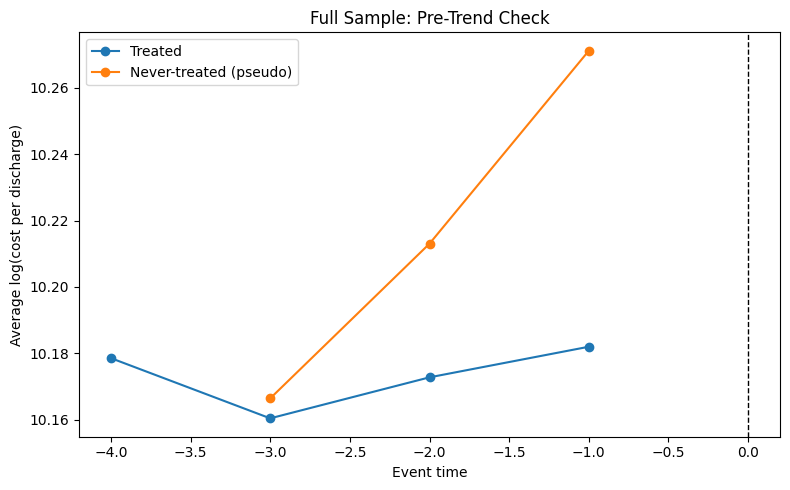

Control pseudo-event reference year: 2014
Pre-period observations: 17600


In [9]:
full_plot, full_reference_year, full_pre_data = build_pretrend_plot_data(df)

plot_pretrend(
    full_plot,
    "Full Sample: Pre-Trend Check",
    "Treated",
    "Never-treated (pseudo)",
    filename="parallel_trend_full_sample.png",
)

print("Control pseudo-event reference year:", full_reference_year)
print("Pre-period observations:", len(full_pre_data))

### Interpretation

In the full sample, the trends for treated and never-treated hospitals before the merger are not parallel. The control group shows a clear upward trend, while the treated group is relatively flat. This suggests that the parallel trends assumption does not hold in the full sample.

Because of this, we cannot fully rely on the DiD identification in the full dataset. As a next step, we explore whether restricting the sample to more comparable groups (such as smaller hospitals or specific ownership types) improves the pre-trend alignment.

## Subgroup analysis: size

Restrict to small hospitals using below-median hospital-level average discharges.

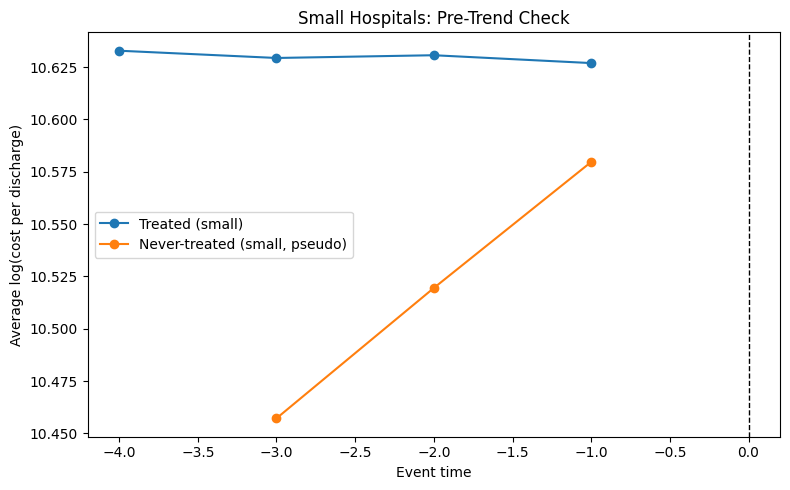

Small-hospital threshold: 1553.0
Pre-period observations: 8369


In [10]:
hospital_mean_discharges = (
    df.groupby("PRVDR_NUM", as_index=False)["total_discharges"]
    .mean()
    .rename(columns={"total_discharges": "hospital_mean_discharges"})
)

small_threshold = hospital_mean_discharges["hospital_mean_discharges"].median()
small_ids = hospital_mean_discharges.loc[
    hospital_mean_discharges["hospital_mean_discharges"] < small_threshold,
    "PRVDR_NUM",
]

df_small = df[df["PRVDR_NUM"].isin(small_ids)].copy()

small_plot, small_reference_year, small_pre_data = build_pretrend_plot_data(df_small)

plot_pretrend(
    small_plot,
    "Small Hospitals: Pre-Trend Check",
    "Treated (small)",
    "Never-treated (small, pseudo)",
    filename="parallel_trend_small_hospitals.png",
)

print("Small-hospital threshold:", round(float(small_threshold), 2))
print("Pre-period observations:", len(small_pre_data))

### Interpretation

In the small-hospital subgroup, pre-treatment trends are still not parallel. The control group shows a clear upward trend, while the treated group remains relatively flat. 

This suggests that restricting the sample by size does not fully resolve the parallel trends issue.

## Subgroup analysis: ownership

Use only ownership categories with enough treated and never-treated hospitals to be viable.

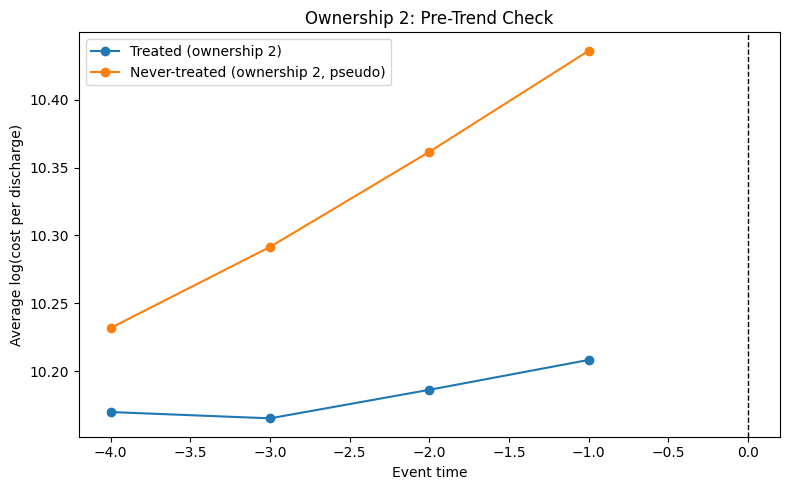

Ownership 2: reference year 2015, pre-period observations 8770


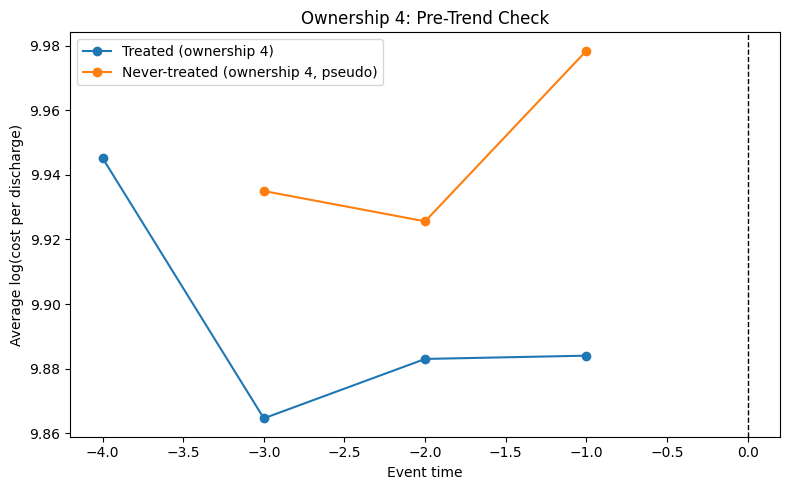

Ownership 4: reference year 2014, pre-period observations 4277


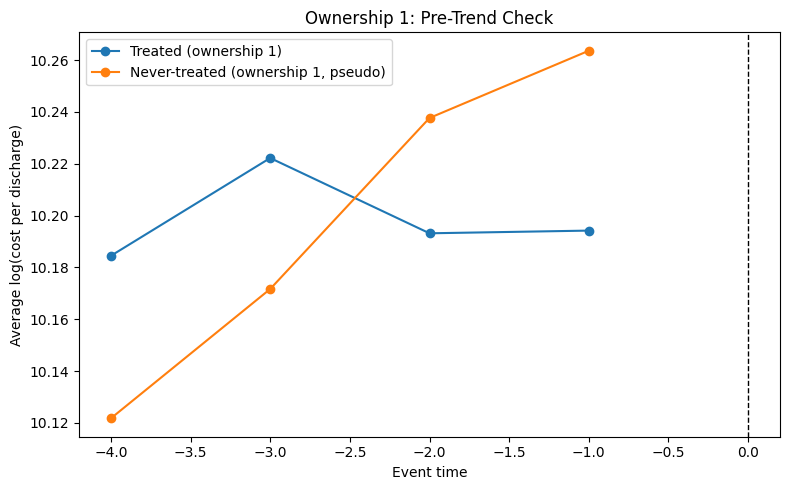

Ownership 1: reference year 2015, pre-period observations 2187


In [11]:
ownership_df = df.copy()
ownership_df["ownership_code"] = ownership_df["PRVDR_CTRL_TYPE_CD"].astype(int)

ownership_focus = [2, 4, 1]

for owner_code in ownership_focus:
    df_owner = ownership_df[ownership_df["ownership_code"] == owner_code].copy()
    owner_plot, owner_reference_year, owner_pre_data = build_pretrend_plot_data(
        df_owner
    )

    plot_pretrend(
        owner_plot,
        f"Ownership {owner_code}: Pre-Trend Check",
        f"Treated (ownership {owner_code})",
        f"Never-treated (ownership {owner_code}, pseudo)",
        filename=f"parallel_trend_ownership_{owner_code}.png",
    )

    print(
        f"Ownership {owner_code}: reference year {owner_reference_year}, pre-period observations {len(owner_pre_data)}"
    )

### Interpretation

Among the ownership subgroups, codes 2, 4, and 1 were kept because they have the largest and most usable samples. These groups provide a more stable comparison than smaller ownership categories.

The pre-trend plots still do not show clear parallel trends. In some groups the lines move somewhat closer, but the slopes are still different. This suggests that restricting the sample by ownership alone does not fully solve the pre-trend problem.

## Subgroup analysis: ownership + size

Final subgroup check: ownership code 2 and small hospitals.

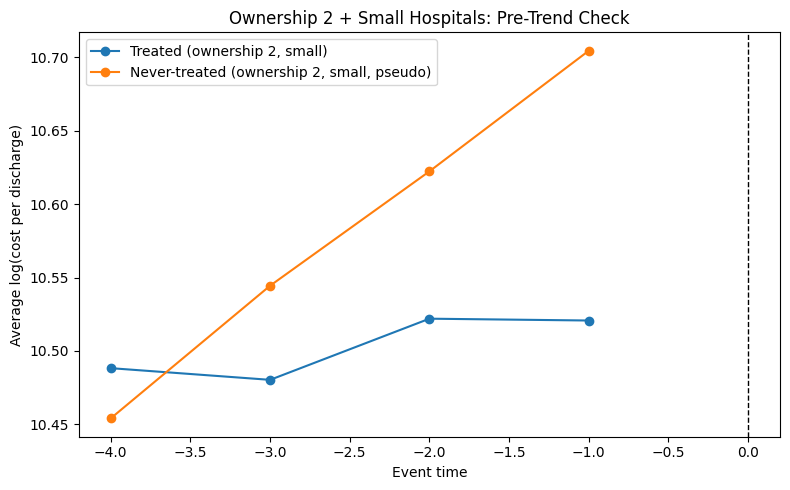

Ownership 2 small-hospital threshold: 2770.33
Pre-period observations: 4268


In [12]:
owner_target = 2
owner_df = ownership_df[ownership_df["ownership_code"] == owner_target].copy()

owner_size = (
    owner_df.groupby("PRVDR_NUM", as_index=False)["total_discharges"]
    .mean()
    .rename(columns={"total_discharges": "hospital_mean_discharges"})
)

owner_small_threshold = owner_size["hospital_mean_discharges"].median()
owner_small_ids = owner_size.loc[
    owner_size["hospital_mean_discharges"] < owner_small_threshold,
    "PRVDR_NUM",
]

owner_small_df = owner_df[owner_df["PRVDR_NUM"].isin(owner_small_ids)].copy()

owner_small_plot, owner_small_reference_year, owner_small_pre_data = (
    build_pretrend_plot_data(owner_small_df)
)

plot_pretrend(
    owner_small_plot,
    "Ownership 2 + Small Hospitals: Pre-Trend Check",
    "Treated (ownership 2, small)",
    "Never-treated (ownership 2, small, pseudo)",
    filename="parallel_trend_ownership_2_small_hospitals.png",
)

print("Ownership 2 small-hospital threshold:", round(float(owner_small_threshold), 2))
print("Pre-period observations:", len(owner_small_pre_data))

### Interpretation

Even after restricting the sample to ownership code 2 and small hospitals, the pre-trend lines are still not parallel. The treated group is relatively flat, while the control group shows a clear upward trend. The gap between the two groups changes over time, which violates the parallel trends assumption.

This suggests that even with both ownership and size restrictions, we are not able to find a subgroup where the parallel trends assumption clearly holds. Therefore, any DiD results should be interpreted with caution.

## Summary of findings

- Full sample is not parallel.
- Size helps a little, but not enough.
- Ownership checks are mixed across viable groups.
- Ownership + size still does not fully solve the issue.

These diagnostics motivate cautious interpretation in the later DiD analysis.